In [93]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import MinMaxScaler


plt.style.use('dark_background')

In [94]:
np.random.seed(7562)

mean, std = 100, 15
pop_normal = MinMaxScaler().fit_transform(np.random.normal(mean, std, 100000).reshape(-1, 1)).flatten()
amostra_normal = np.random.choice(pop_normal, size=50)

df_t = 10
pop_t = MinMaxScaler().fit_transform(np.random.standard_t(df_t, 100000).reshape(-1, 1)).flatten()
amostra_t = np.random.choice(pop_t, size=50)

## Métodos gráficos

In [95]:
def ssplot(
    plot_func,
    titulo_geral="Comparação de Distribuições",
    func_args=None,
    func_kwargs=None,
):
    """
    Desenha um layout 2x2 usando as variáveis globais:
      - linha 1: pop_normal e pop_t
      - linha 2: amostra_normal e amostra_t

    O parâmetro plot_func deve ser uma função do seaborn. Os argumentos
    extras serão repassados automaticamente para cada chamada.
    """
    if func_args is None:
        func_args = ()
    if func_kwargs is None:
        func_kwargs = {}

    fig, axes = plt.subplots(2, 2, figsize=(12, 9))
    plots = [
        (pop_normal, "Pop Normal", "skyblue"),
        (pop_t, f"Pop T (df={df_t})", "salmon"),
        (amostra_normal, "Amostra Normal", "skyblue"),
        (amostra_t, f"Amostra T (df={df_t})", "salmon"),
    ]

    for ax, (data, title, default_color) in zip(axes.flat, plots):
        plot_kwargs = func_kwargs.copy()
        if "color" not in plot_kwargs and "palette" not in plot_kwargs:
            plot_kwargs["color"] = default_color

        if plot_func is sns.scatterplot or getattr(plot_func, "__name__", "") == "scatterplot":
            plot_func(x=np.arange(len(data)), y=data, ax=ax, *func_args, **plot_kwargs)
        elif getattr(plot_func, "__name__", "") == "qqplot":
            plot_func(data, ax=ax, *func_args)
        else:
            plot_func(x=data, ax=ax, *func_args, **plot_kwargs)

        ax.set_title(title)

    plt.suptitle(titulo_geral)

    plt.tight_layout()
    plt.show()

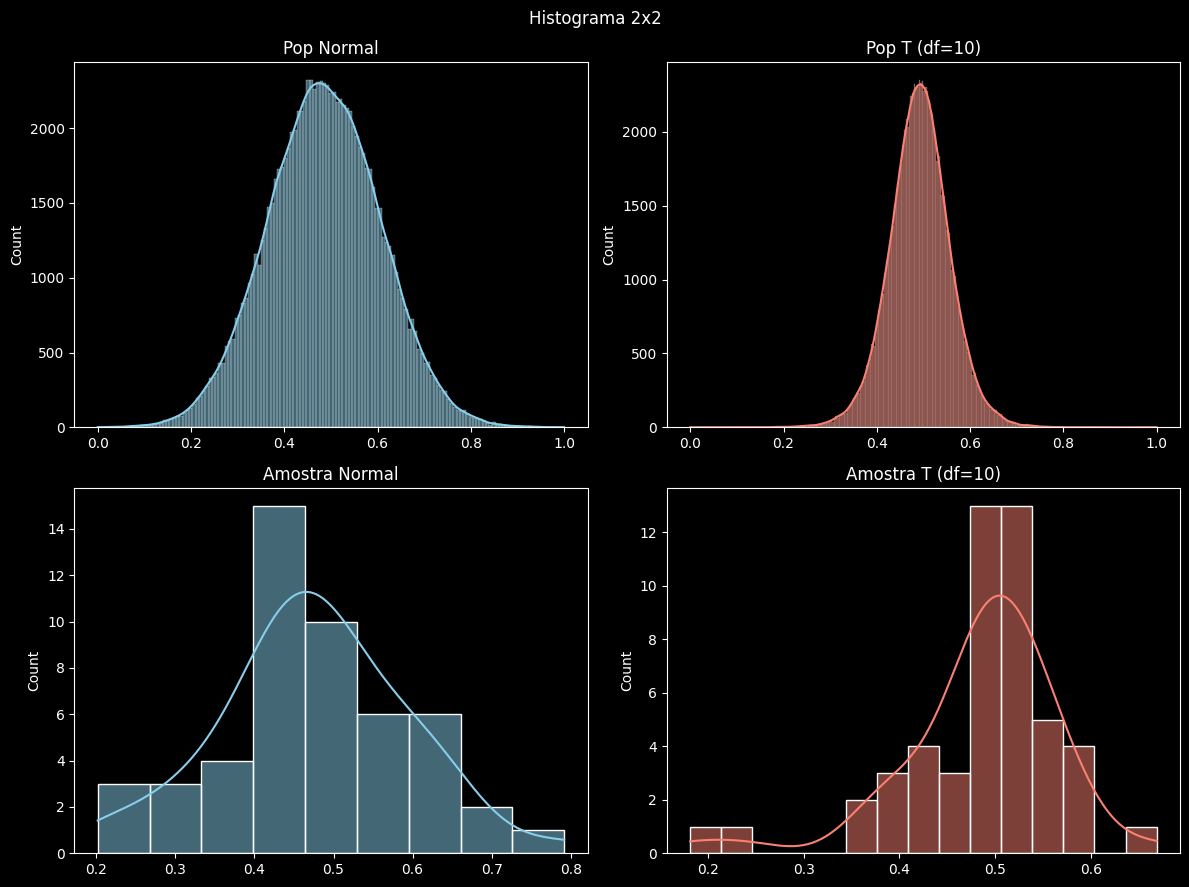

In [96]:
ssplot(sns.histplot, titulo_geral="Histograma 2x2", func_kwargs={"kde": True})

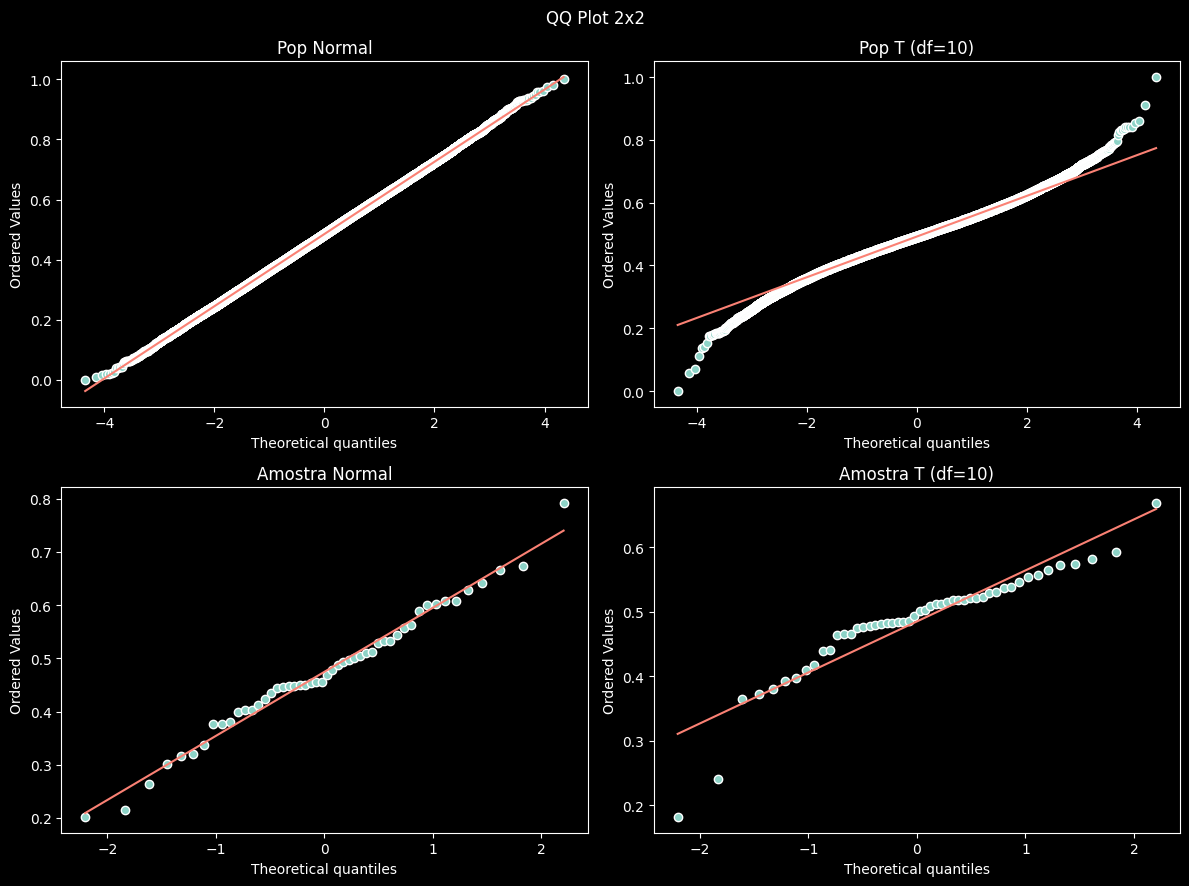

In [97]:
def qqplot(data, ax):
    res = stats.probplot(data, plot=ax)
    ax.get_lines()[0].set_markerfacecolor(sns.color_palette()[0])
    ax.get_lines()[0].set_markeredgecolor('white')
    ax.get_lines()[1].set_color(sns.color_palette()[3])

ssplot(qqplot, titulo_geral="QQ Plot 2x2")

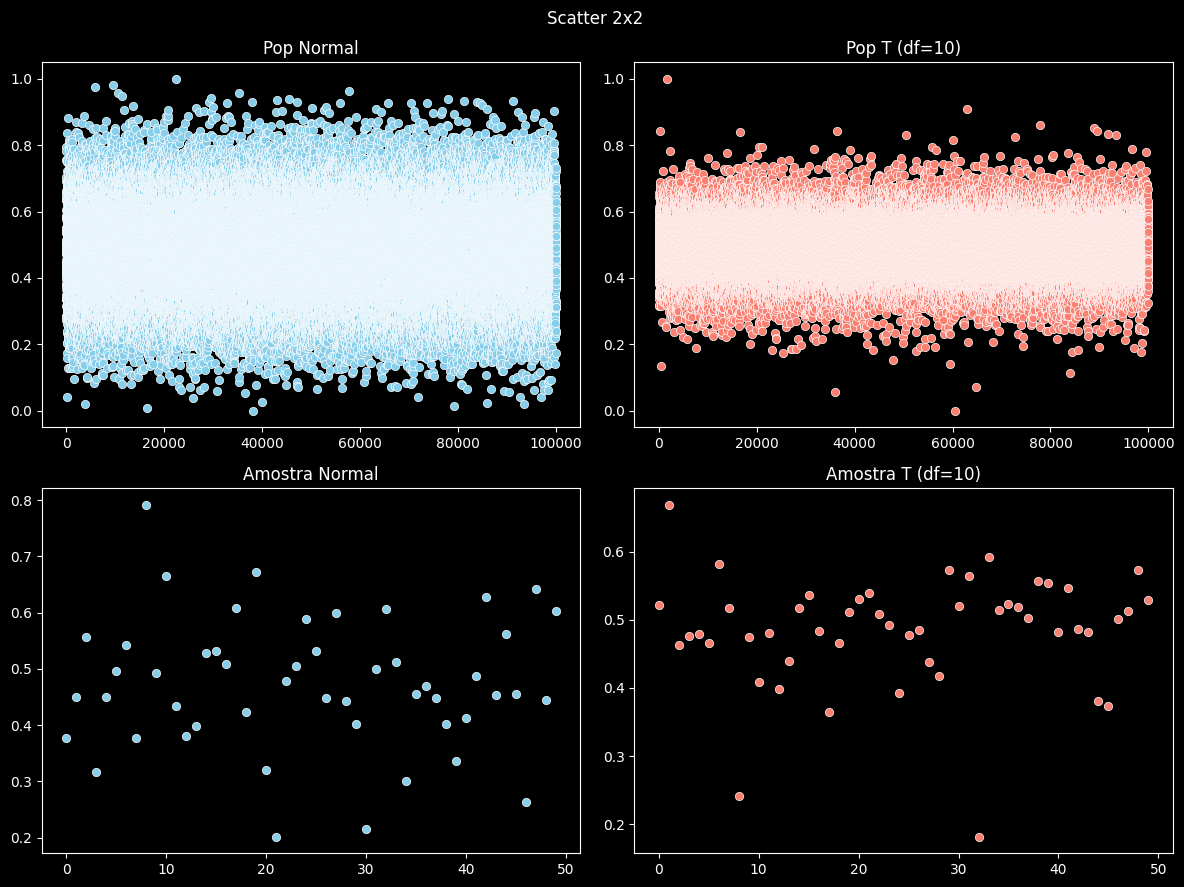

In [98]:
ssplot(sns.scatterplot, titulo_geral="Scatter 2x2")

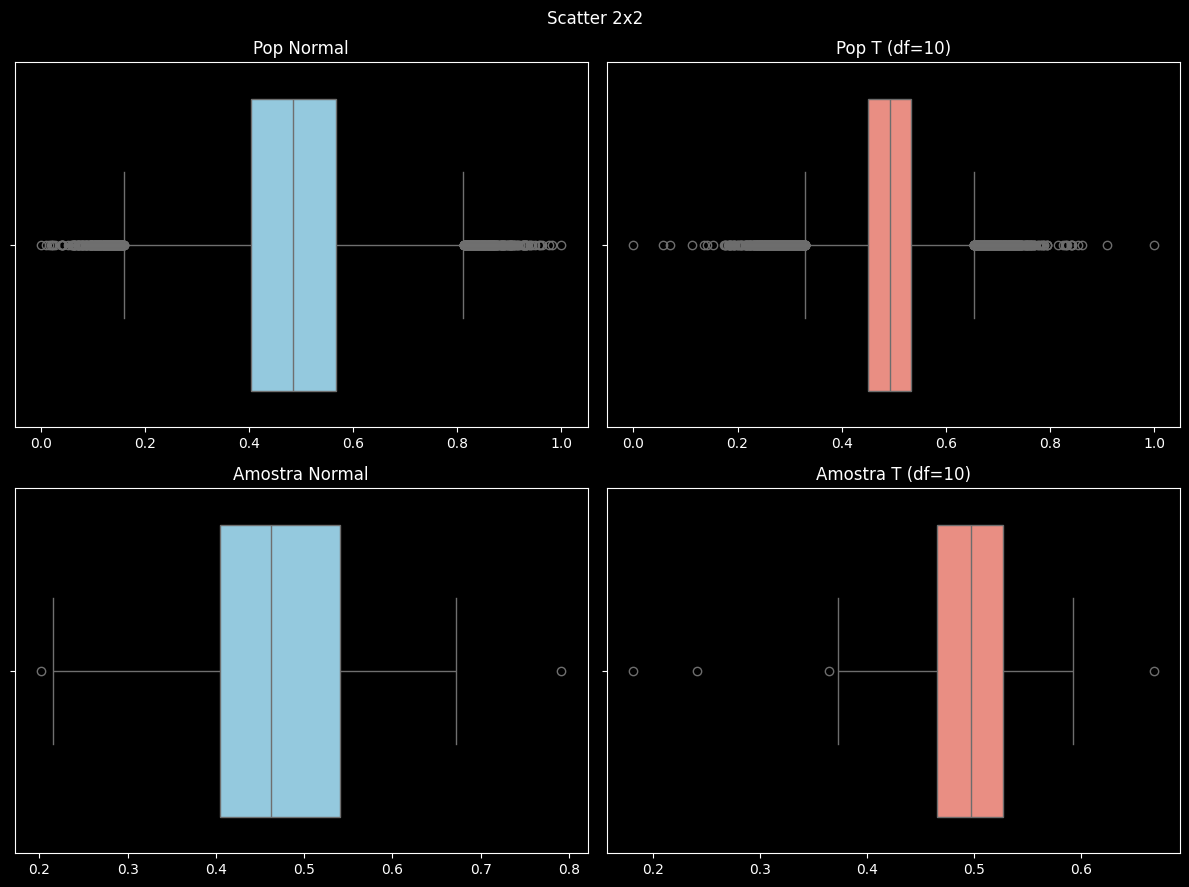

In [99]:
ssplot(sns.boxplot, titulo_geral="Scatter 2x2")

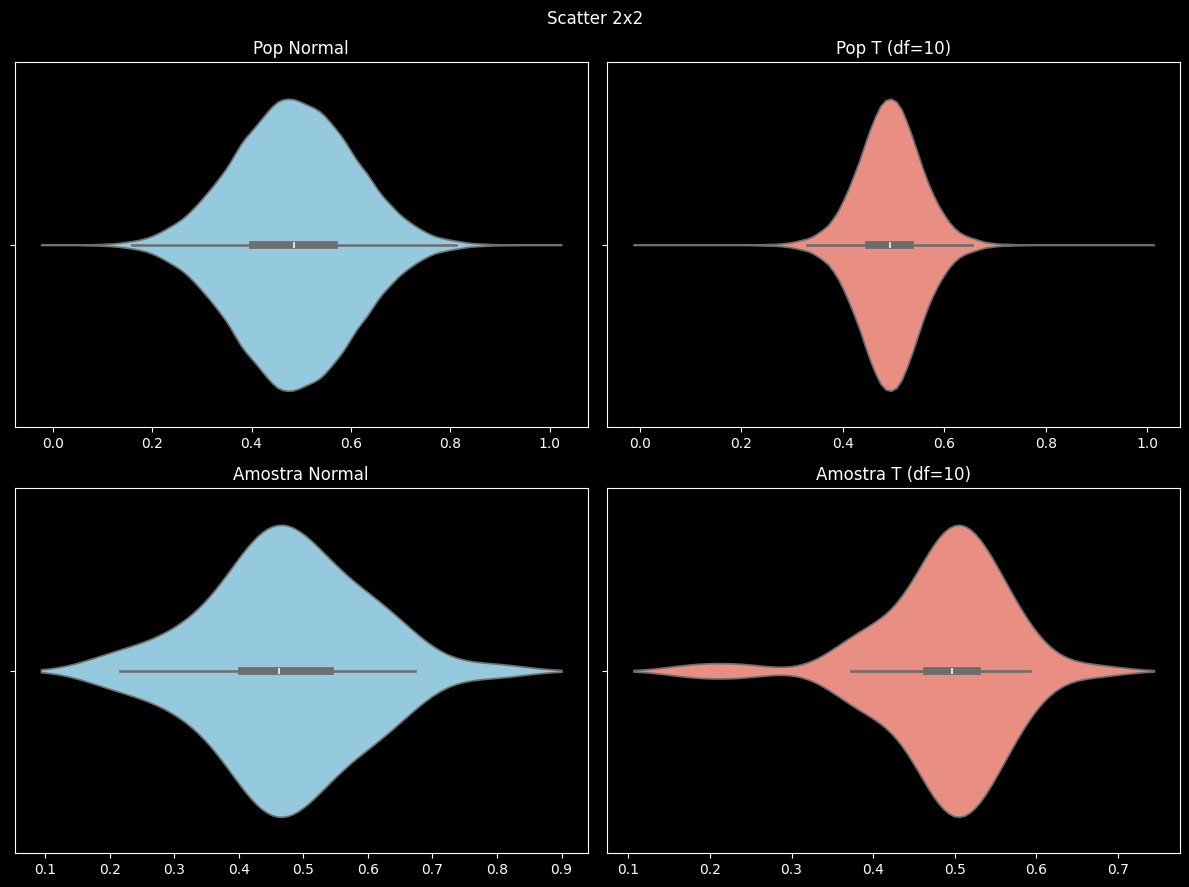

In [100]:
ssplot(sns.violinplot, titulo_geral="Scatter 2x2")

### Assimetria e curtose

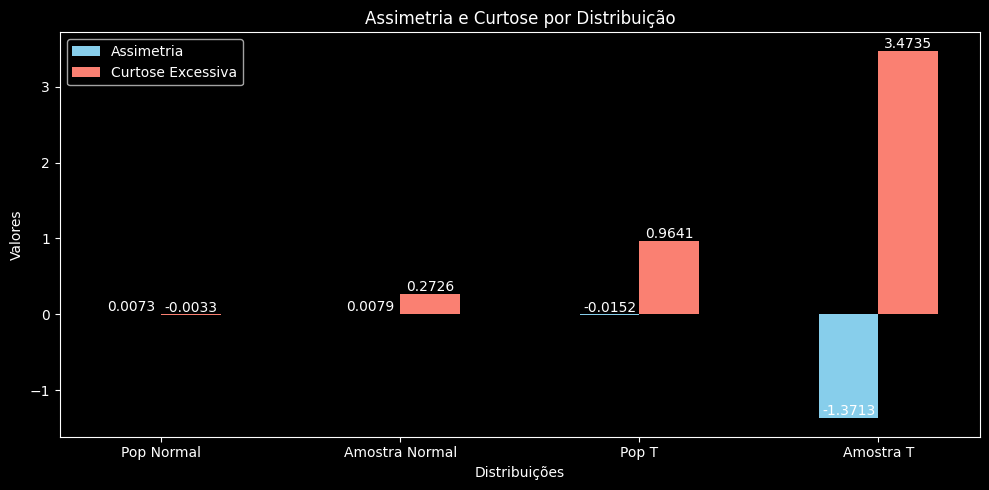

In [115]:
distributions = [pop_normal, amostra_normal, pop_t, amostra_t]
names = ["Pop Normal", "Amostra Normal", "Pop T", "Amostra T"]

skew_values = [stats.skew(data, bias=True) for data in distributions]
kurtosis_values = [stats.kurtosis(data, bias=True) for data in distributions]

# Preparar dados para barras agrupadas
x = np.arange(len(names))  # posições para cada distribuição
width = 0.25  # largura das barras

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, skew_values, width, label='Assimetria', color='skyblue')
bars2 = ax.bar(x + width/2, kurtosis_values, width, label='Curtose Excessiva', color='salmon')

ax.set_xlabel('Distribuições')
ax.set_ylabel('Valores')
ax.set_title('Assimetria e Curtose por Distribuição')
ax.set_xticks(x)
ax.set_xticklabels(names)
ax.legend()

# Adicionar valores nas barras
for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height, f'{height:.4f}', ha='center', va='bottom')

for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height, f'{height:.4f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

## Metodos formais

### Ryan-Joiner

In [122]:
def ryan_joiner_test(data):
    # 1. Ordenar os dados (x_j)
    x = np.sort(data)
    n = len(x)
    
    # 2. Calcular as probabilidades para os quantis teóricos
    # Usamos a aproximação de Blom: (i - 0.375) / (n + 0.25)
    i = np.arange(1, n + 1)
    probabilities = (i - 0.375) / (n + 0.25)
    
    # 3. Calcular os quantis teóricos da Normal Padrão (q_j)
    q = stats.norm.ppf(probabilities)
    
    # 4. Calcular a correlação de Pearson entre x e q
    correlation, _ = stats.pearsonr(x, q)
    
    return correlation

rqs = [
    ryan_joiner_test(pop_normal),
    ryan_joiner_test(amostra_normal),
    ryan_joiner_test(pop_t),
    ryan_joiner_test(amostra_t),    
]
names = ["Pop Normal", "Amostra Normal", "Pop T", "Amostra T"]
significance_threshold = 0.9768

for name, r in zip(names, rqs):
    print(f"{name}: Correlação = {r:.4f}")
    if r > significance_threshold:
        print("Parece ser Normal (Correlação > threshold)")
    else:
        print("Não é Normal (Correlação <= threshold)")
    print('-'*40)


Pop Normal: Correlação = 1.0000
Parece ser Normal (Correlação > threshold)
----------------------------------------
Amostra Normal: Correlação = 0.9925
Parece ser Normal (Correlação > threshold)
----------------------------------------
Pop T: Correlação = 0.9973
Parece ser Normal (Correlação > threshold)
----------------------------------------
Amostra T: Correlação = 0.9367
Não é Normal (Correlação <= threshold)
----------------------------------------


### Shapiro-Wilk

In [121]:
def shapiro_wilk(*args):
    for data in args:
        print('-'*40)
        stat, p_value = stats.shapiro(data)

        print(f"Estatística W: {stat:.4f}")
        print(f"p-valor: {p_value:.4f}")

        if p_value > 0.05:
            print("Amostra parece ser Normal (Não rejeita H0)")
        else:
            print("Amostra não é Normal (Rejeita H0)")

shapiro_wilk(pop_normal, amostra_normal, pop_t, amostra_t)

----------------------------------------
Estatística W: 1.0000
p-valor: 0.6741
Amostra parece ser Normal (Não rejeita H0)
----------------------------------------
Estatística W: 0.9878
p-valor: 0.8825
Amostra parece ser Normal (Não rejeita H0)
----------------------------------------
Estatística W: 0.9947
p-valor: 0.0000
Amostra não é Normal (Rejeita H0)
----------------------------------------
Estatística W: 0.8907
p-valor: 0.0002
Amostra não é Normal (Rejeita H0)


### Komolgorov